# 06 — Model Training: S2 vs. S1 vs. S2+S1 Fusion

**Author:** Florian Klaver

**Prerequisite:** Notebook 05 must have produced `data/training_samples_fusion.csv`.

---

## Experiment design

All four configurations train and test on the **same events** (the fusion-eligible subset).
This guarantees that any performance difference is due to the feature set, not the data split.

| Config | Feature set | Purpose |
|---|---|---|
| **S2-only** | 20 S2 features | Retrained baseline — fair comparison on reduced event set |
| **S1-only** | 6 SAR features | Upper bound for SAR alone; shows standalone S1 value |
| **S2+S1 fusion** | 26 features (all) | Main thesis contribution |
| **Hybrid+SAR ablation** | 4 S2 hybrid + 6 SAR = 10 features | Lightweight fusion with best S2 features from PA2 |

For each config: **Tuned Random Forest** (fastest to tune) + **Tuned SVM** (best in PA2).
GroupShuffleSplit(group=match_id) prevents temporal data leakage.

---
## 1. Setup & Load Data

In [23]:
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..'))
from src.evaluation import (
    FEATURE_NAMES, prepare_data, evaluate_model,
    train_tuned_svm, train_tuned_rf, train_tuned_lgbm
)

FUSION_CSV   = r'..\data\training_samples_fusion.csv'
MODELS_DIR   = r'..\models'
os.makedirs(MODELS_DIR, exist_ok=True)

SAR_FEATURES = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
# Best 4 S2 features from PA2 hybrid model
S2_HYBRID_FEATURES = ['ndii_diff', 'ndii_after', 'gndvi_diff', 'swir_after']

fusion_df = pd.read_csv(FUSION_CSV)
print(f'Fusion samples: {len(fusion_df)} rows, {fusion_df["match_id"].nunique()} events')
print(f'Class balance:  {fusion_df["label"].value_counts().to_dict()}')

COH_CSV      = r'..\data\training_samples_fusion_coh.csv'
COH_FEATURES = ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']

coh_raw = pd.read_csv(COH_CSV)
coh_df  = coh_raw.dropna(subset=COH_FEATURES).copy()
print(f'Coherence samples: {len(coh_df)} rows, {coh_df["match_id"].nunique()} events')

Fusion samples: 33368 rows, 63 events
Class balance:  {1: 18077, 0: 15291}
Coherence samples: 16843 rows, 32 events


---
## 2. Shared Train/Test Split

A single GroupShuffleSplit is applied once and reused for all 4 configurations.
This ensures the same test events are held out for every model — fair comparison.

In [24]:
# Split on all 26 features — we will subset columns per config
all_features = FEATURE_NAMES + SAR_FEATURES
X_train_all, y_train, groups_train, X_test_all, y_test = prepare_data(
    fusion_df, all_features, random_state=42
)

print(f'\nTrain events: {groups_train.nunique()}')
print(f'Test  events: {fusion_df.loc[X_test_all.index, "match_id"].nunique()}')

Training: 24945 samples (50 matches)
Testing:  8423 samples (13 matches)

Train events: 50
Test  events: 13


---
## 3. Config 1: S2-Only Baseline (retrained on fusion-eligible events)

=== Config 1: S2-only (20 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2-only RF ---
Accuracy: 91.06%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.97      0.91      3702
    Mowed (1)       0.98      0.86      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



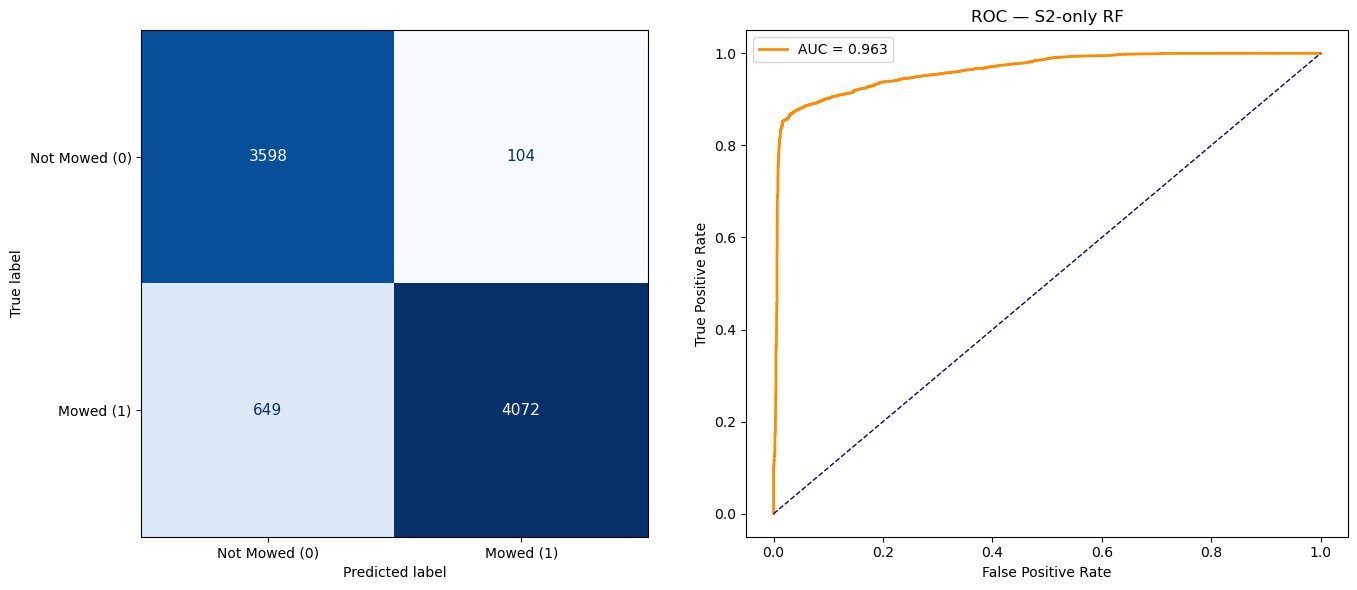

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2-only SVM ---
Accuracy: 91.52%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.98      0.91      3702
    Mowed (1)       0.98      0.86      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.92      0.91      8423
 weighted avg       0.92      0.92      0.92      8423



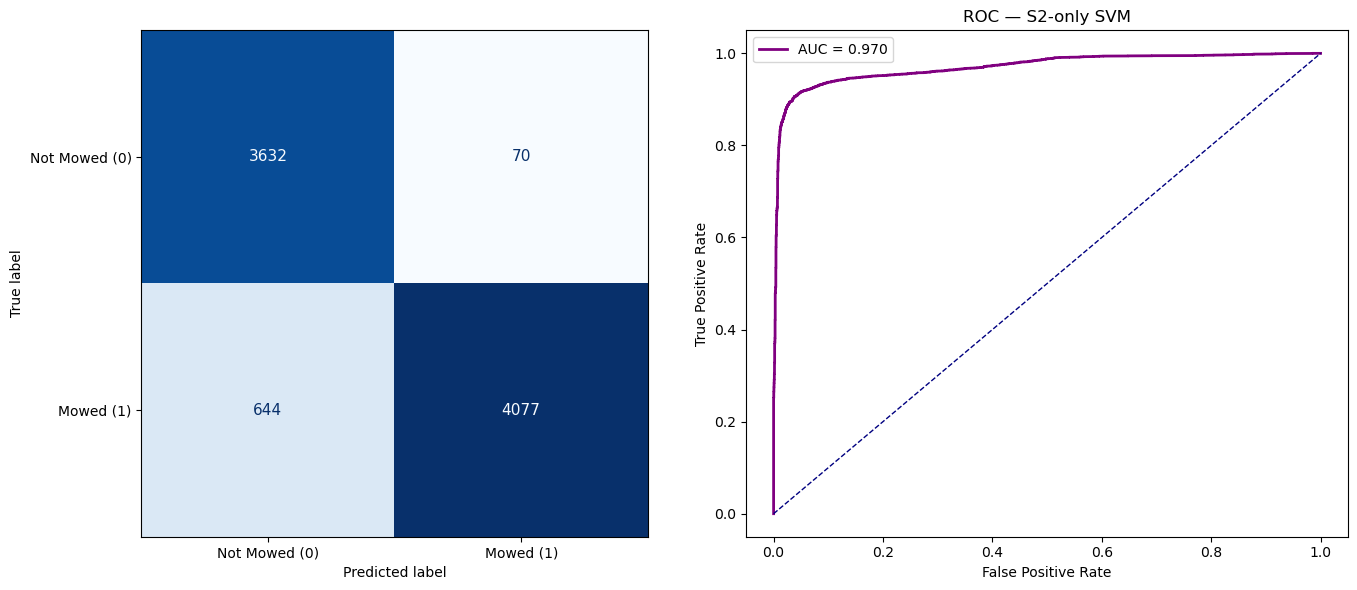

In [25]:
results = []

X_train_s2 = X_train_all[FEATURE_NAMES]
X_test_s2  = X_test_all[FEATURE_NAMES]

print('=== Config 1: S2-only (20 features) ===')
model_s2_rf = train_tuned_rf(
    X_train_s2, y_train, groups_train, X_test_s2, y_test,
    results_list=results, model_alias='S2-only RF'
)
model_s2_svm = train_tuned_svm(
    X_train_s2, y_train, groups_train, X_test_s2, y_test,
    results_list=results, model_alias='S2-only SVM'
)

---
## 4. Config 2: S1-Only (6 SAR features)

=== Config 2: S1-only (6 SAR features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- S1-only RF ---
Accuracy: 53.53%
               precision    recall  f1-score   support

Not Mowed (0)       0.46      0.38      0.42      3702
    Mowed (1)       0.57      0.66      0.61      4721

     accuracy                           0.54      8423
    macro avg       0.52      0.52      0.52      8423
 weighted avg       0.53      0.54      0.53      8423



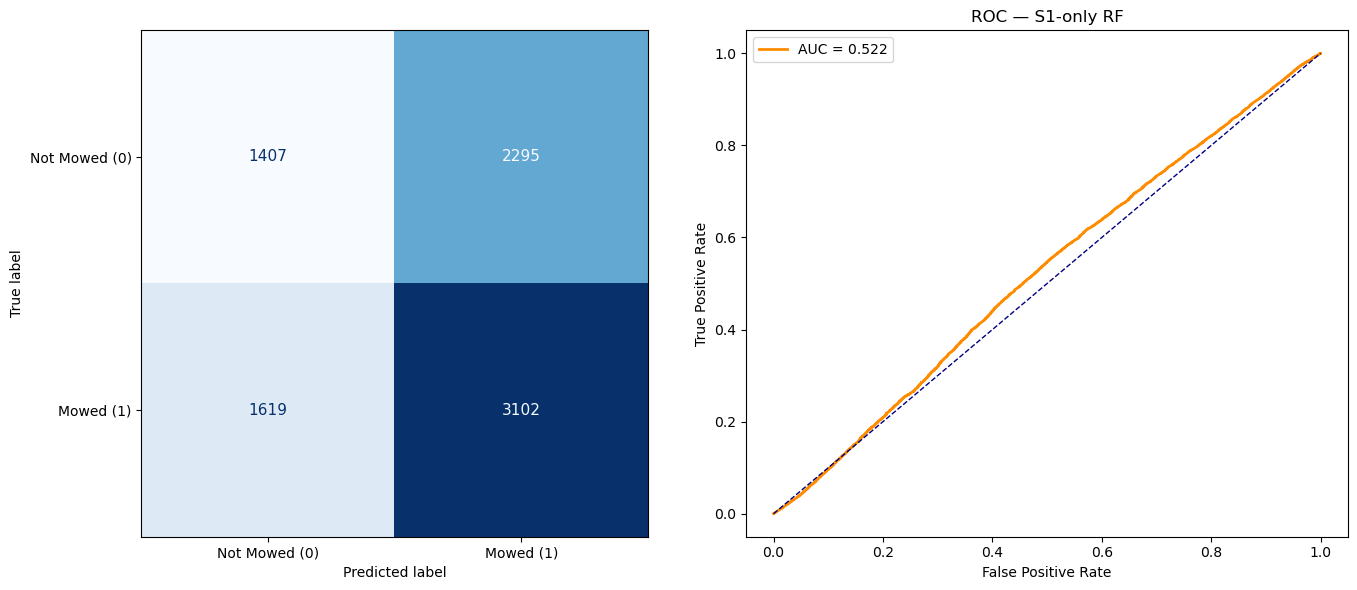

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S1-only SVM ---
Accuracy: 55.46%
               precision    recall  f1-score   support

Not Mowed (0)       0.48      0.13      0.20      3702
    Mowed (1)       0.57      0.89      0.69      4721

     accuracy                           0.55      8423
    macro avg       0.52      0.51      0.45      8423
 weighted avg       0.53      0.55      0.48      8423



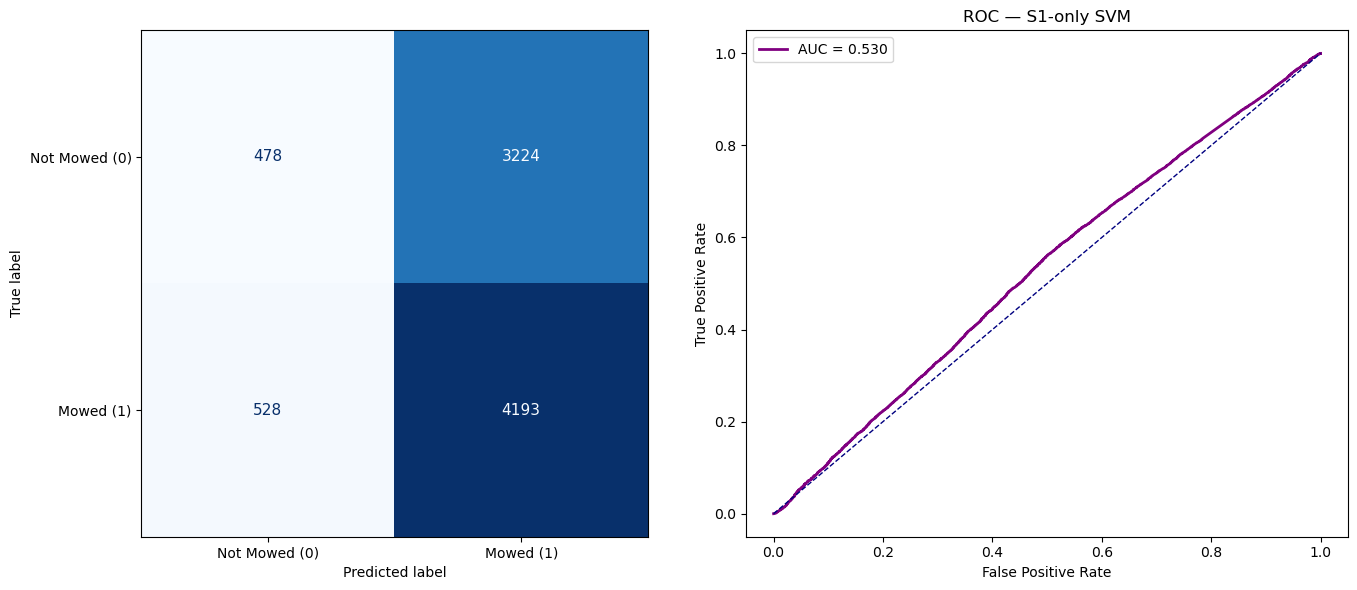

In [26]:
X_train_s1 = X_train_all[SAR_FEATURES]
X_test_s1  = X_test_all[SAR_FEATURES]

print('=== Config 2: S1-only (6 SAR features) ===')
model_s1_rf = train_tuned_rf(
    X_train_s1, y_train, groups_train, X_test_s1, y_test,
    results_list=results, model_alias='S1-only RF'
)
model_s1_svm = train_tuned_svm(
    X_train_s1, y_train, groups_train, X_test_s1, y_test,
    results_list=results, model_alias='S1-only SVM'
)

---
## 5. Config 3: S2+S1 Fusion (26 features)

=== Config 3: S2+S1 Fusion (26 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': None, 'rf__n_estimators': 100}

--- S2+S1 Fusion RF ---
Accuracy: 90.72%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.97      0.87      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.91      0.91      8423
 weighted avg       0.91      0.91      0.91      8423



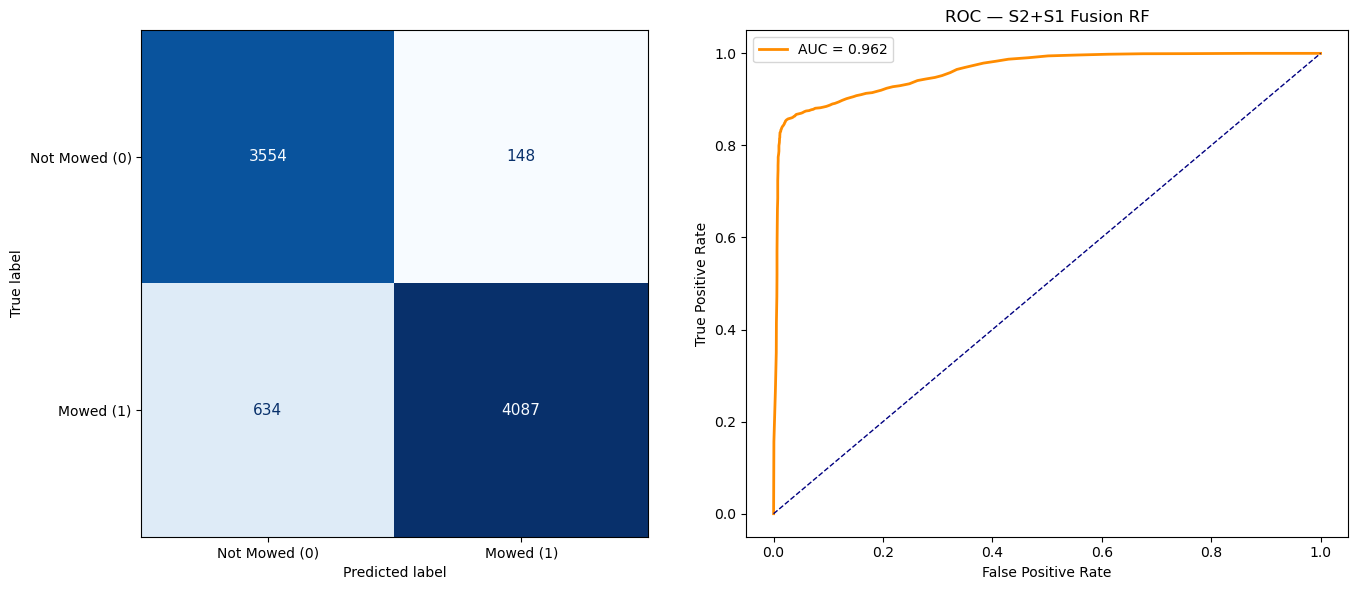

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2+S1 Fusion SVM ---
Accuracy: 90.97%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.97      0.90      3702
    Mowed (1)       0.97      0.86      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



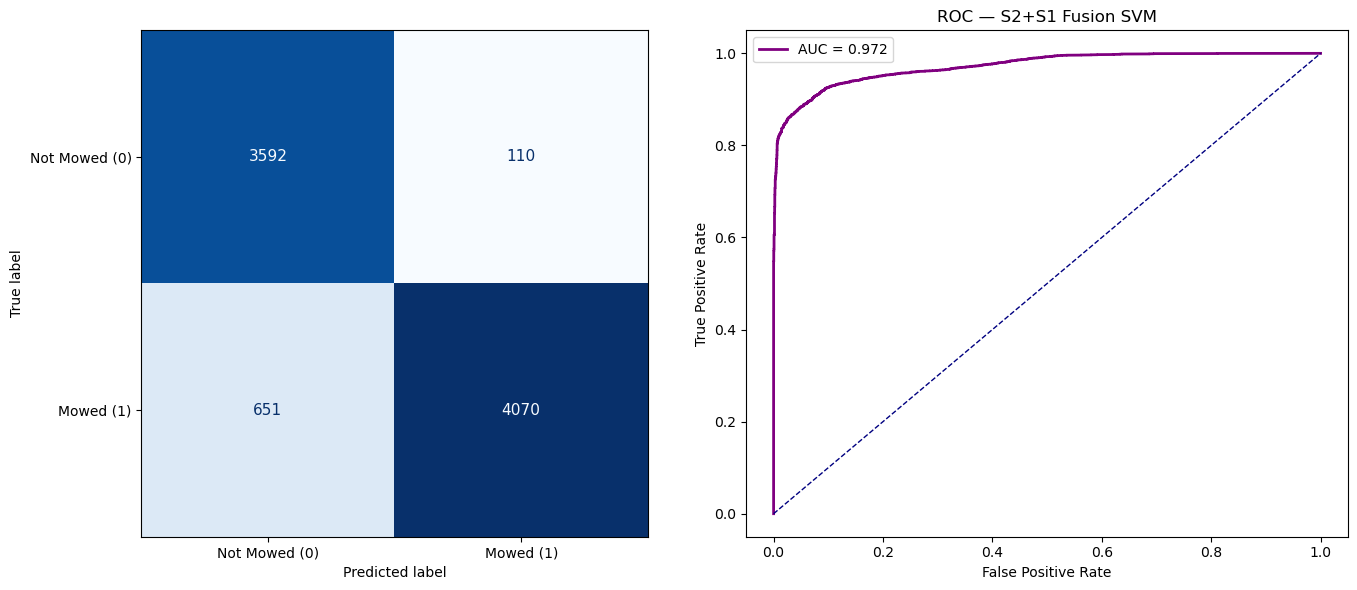

In [27]:
X_train_fusion = X_train_all[FEATURE_NAMES + SAR_FEATURES]
X_test_fusion  = X_test_all[FEATURE_NAMES + SAR_FEATURES]

print('=== Config 3: S2+S1 Fusion (26 features) ===')
model_fusion_rf = train_tuned_rf(
    X_train_fusion, y_train, groups_train, X_test_fusion, y_test,
    results_list=results, model_alias='S2+S1 Fusion RF'
)
model_fusion_svm = train_tuned_svm(
    X_train_fusion, y_train, groups_train, X_test_fusion, y_test,
    results_list=results, model_alias='S2+S1 Fusion SVM'
)

---
## 6. Config 4: Hybrid Ablation (4 best S2 + 6 SAR = 10 features)

The PA2 best model (Hybrid SVM) used just 4 S2 features: `ndii_diff`, `ndii_after`,
`gndvi_diff`, `swir_after`. Adding the 6 SAR features to this lean set tests whether
SAR adds value on top of the most discriminative optical features.

=== Config 4: Hybrid+SAR ablation (10 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- Hybrid+SAR RF ---
Accuracy: 91.63%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.97      0.91      3702
    Mowed (1)       0.97      0.88      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.92      0.92      8423
 weighted avg       0.92      0.92      0.92      8423



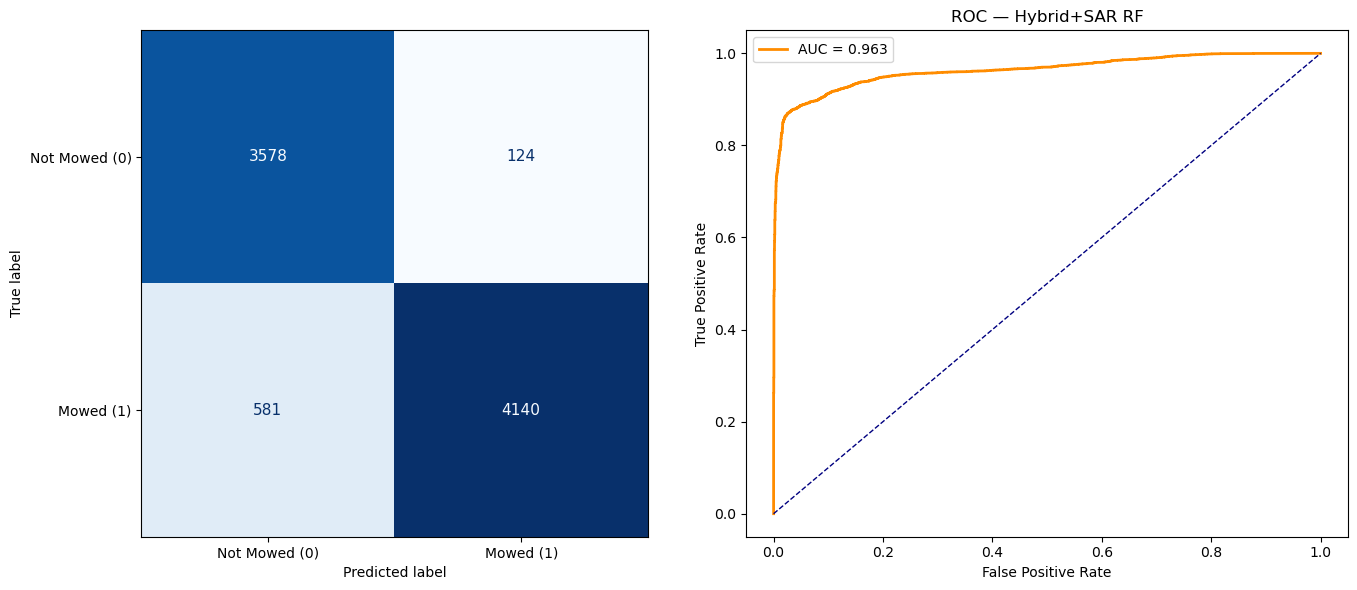

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- Hybrid+SAR SVM ---
Accuracy: 90.72%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.95      0.90      3702
    Mowed (1)       0.96      0.87      0.91      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.91      0.91      8423
 weighted avg       0.91      0.91      0.91      8423



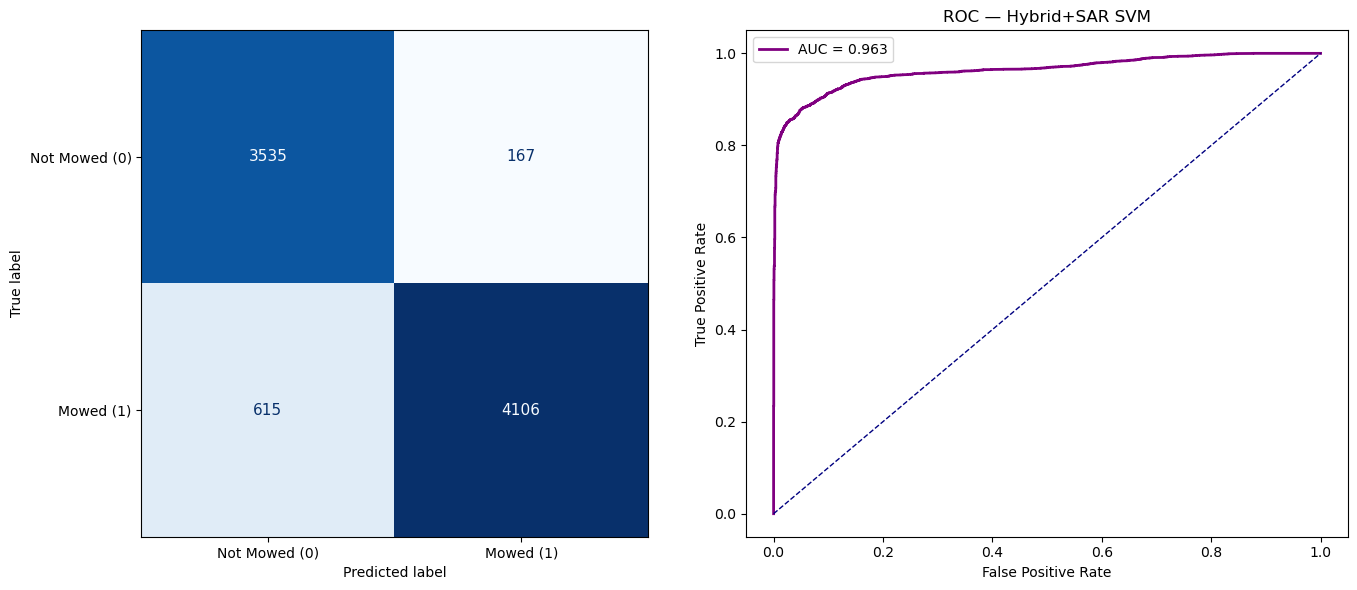

In [28]:
hybrid_sar_features = S2_HYBRID_FEATURES + SAR_FEATURES
X_train_hyb = X_train_all[hybrid_sar_features]
X_test_hyb  = X_test_all[hybrid_sar_features]

print('=== Config 4: Hybrid+SAR ablation (10 features) ===')
model_hyb_rf = train_tuned_rf(
    X_train_hyb, y_train, groups_train, X_test_hyb, y_test,
    results_list=results, model_alias='Hybrid+SAR RF'
)
model_hyb_svm = train_tuned_svm(
    X_train_hyb, y_train, groups_train, X_test_hyb, y_test,
    results_list=results, model_alias='Hybrid+SAR SVM'
)

---
## 5. Coherence Feature Configurations

All four coherence configs train on the **coherence-eligible subset** (events where
both  and  were successfully computed — 0 events).
A separate GroupShuffleSplit is applied so results within this group are directly comparable.

Note: configs 1–4 above use all 63 GRD-eligible events; configs 5–8 use the coherence
subset only. Compare within each group for fair ablation.

In [29]:
# === COHERENCE SECTION SETUP ===
# Load coherence-eligible subset and create a shared split for all coherence configs.
# Only events where all 4 coherence features are non-NaN are included.
# GroupShuffleSplit(group=match_id) prevents temporal data leakage.

coh_results = []

all_coh_features = FEATURE_NAMES + SAR_FEATURES + COH_FEATURES
X_train_coh_all, y_train_coh, groups_train_coh, X_test_coh_all, y_test_coh = prepare_data(
    coh_df, all_coh_features, random_state=42
)

print(f'Coherence group — Train events: {groups_train_coh.nunique()}')
print(f'Coherence group — Test  events: {coh_df.loc[X_test_coh_all.index, "match_id"].nunique()}')


Training: 13556 samples (25 matches)
Testing:  3287 samples (7 matches)
Coherence group — Train events: 25
Coherence group — Test  events: 7


### Config 5: Coherence-Only (4 features)

Establishes the standalone value of InSAR coherence without any optical or backscatter input.
Analogue of Config 2 (S1-only) for the coherence modality.

=== Config 5: Coherence-only (4 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- Coh-only RF ---
Accuracy: 79.95%
               precision    recall  f1-score   support

Not Mowed (0)       0.83      0.77      0.80      1684
    Mowed (1)       0.77      0.83      0.80      1603

     accuracy                           0.80      3287
    macro avg       0.80      0.80      0.80      3287
 weighted avg       0.80      0.80      0.80      3287



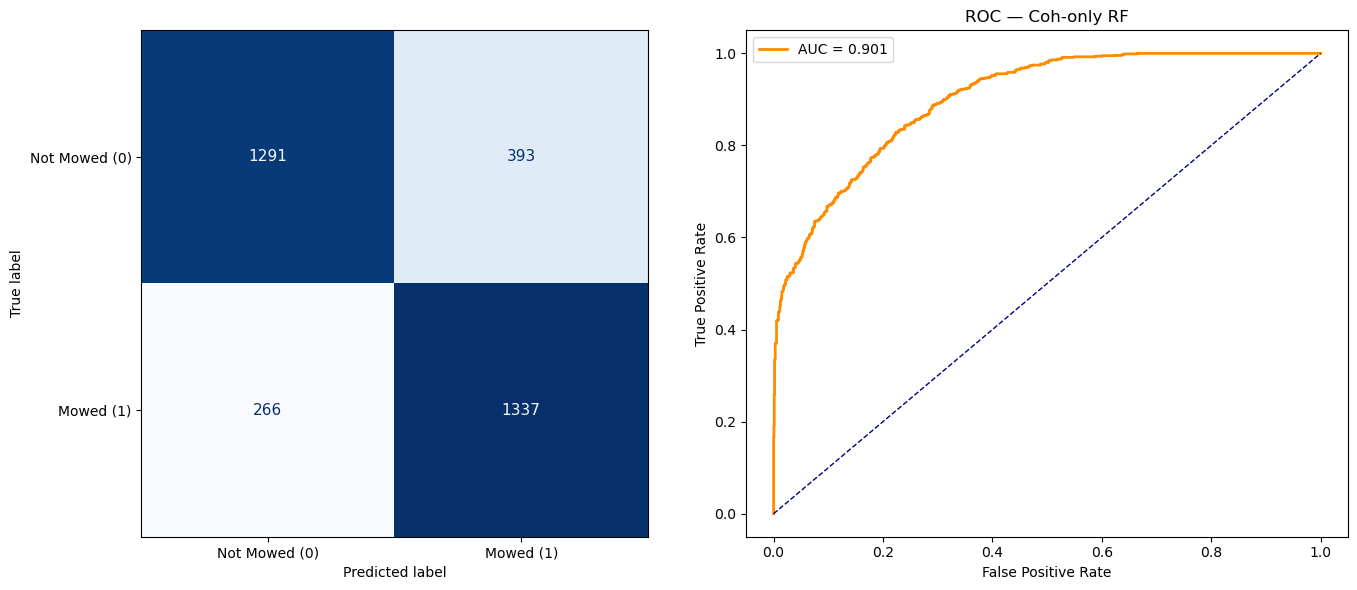

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}

--- Coh-only SVM ---
Accuracy: 81.29%
               precision    recall  f1-score   support

Not Mowed (0)       0.84      0.78      0.81      1684
    Mowed (1)       0.79      0.85      0.82      1603

     accuracy                           0.81      3287
    macro avg       0.81      0.81      0.81      3287
 weighted avg       0.82      0.81      0.81      3287



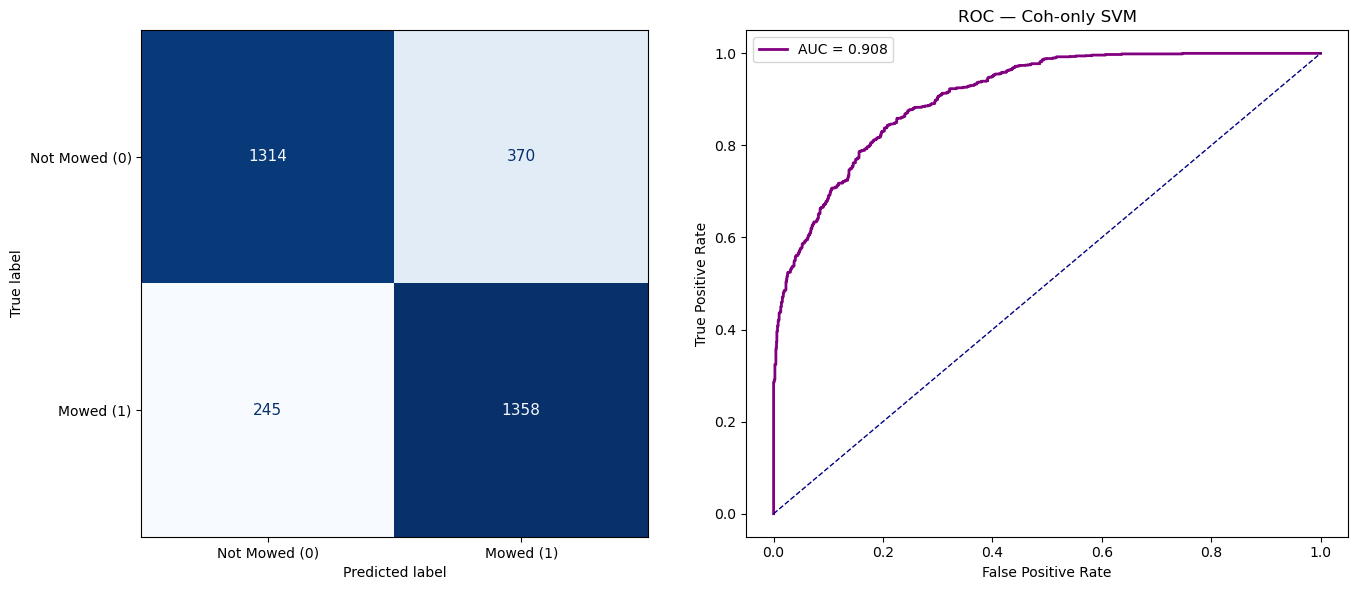

In [30]:
X_train_co = X_train_coh_all[COH_FEATURES]
X_test_co  = X_test_coh_all[COH_FEATURES]

print('=== Config 5: Coherence-only (4 features) ===')
model_co_rf = train_tuned_rf(
    X_train_co, y_train_coh, groups_train_coh, X_test_co, y_test_coh,
    results_list=coh_results, model_alias='Coh-only RF'
)
model_co_svm = train_tuned_svm(
    X_train_co, y_train_coh, groups_train_coh, X_test_co, y_test_coh,
    results_list=coh_results, model_alias='Coh-only SVM'
)


### Config 6: SAR + Coherence (10 features)

Combines GRD backscatter (6) and coherence (4) — a pure SAR model with no optical input.
Tests whether coherence meaningfully improves over backscatter alone (Config 2).

=== Config 6: SAR+Coh (10 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 200}

--- SAR+Coh RF ---
Accuracy: 77.55%
               precision    recall  f1-score   support

Not Mowed (0)       0.80      0.76      0.78      1684
    Mowed (1)       0.76      0.80      0.78      1603

     accuracy                           0.78      3287
    macro avg       0.78      0.78      0.78      3287
 weighted avg       0.78      0.78      0.78      3287



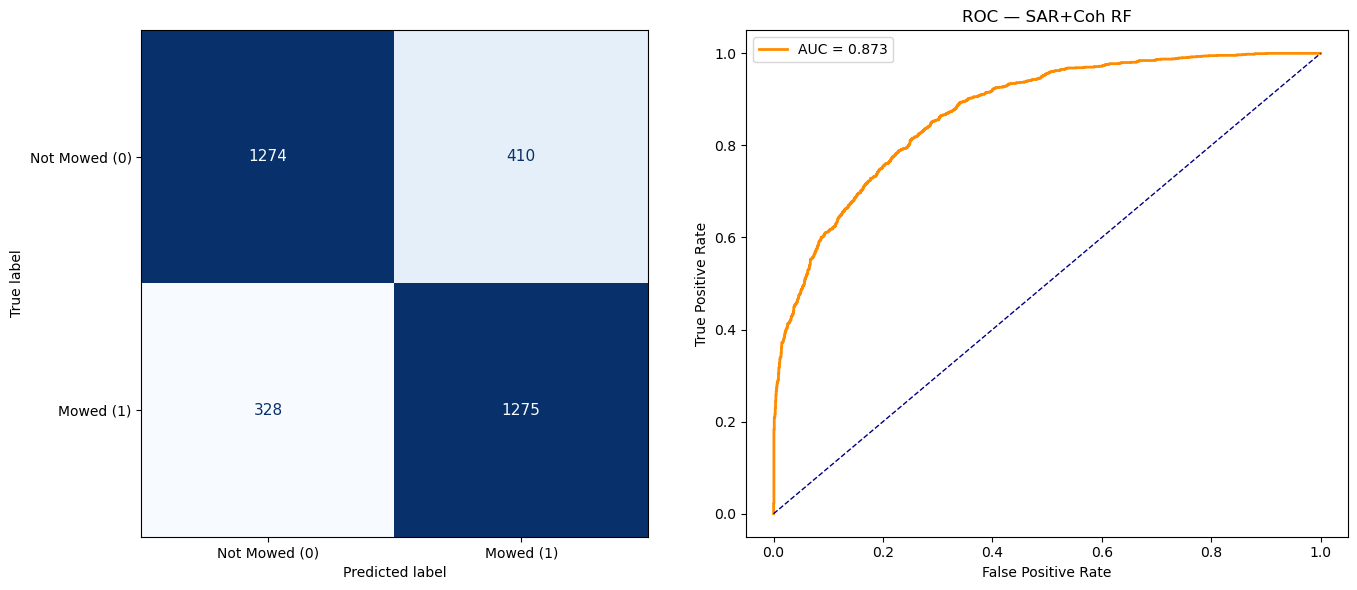

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- SAR+Coh SVM ---
Accuracy: 77.58%
               precision    recall  f1-score   support

Not Mowed (0)       0.79      0.76      0.78      1684
    Mowed (1)       0.76      0.79      0.77      1603

     accuracy                           0.78      3287
    macro avg       0.78      0.78      0.78      3287
 weighted avg       0.78      0.78      0.78      3287



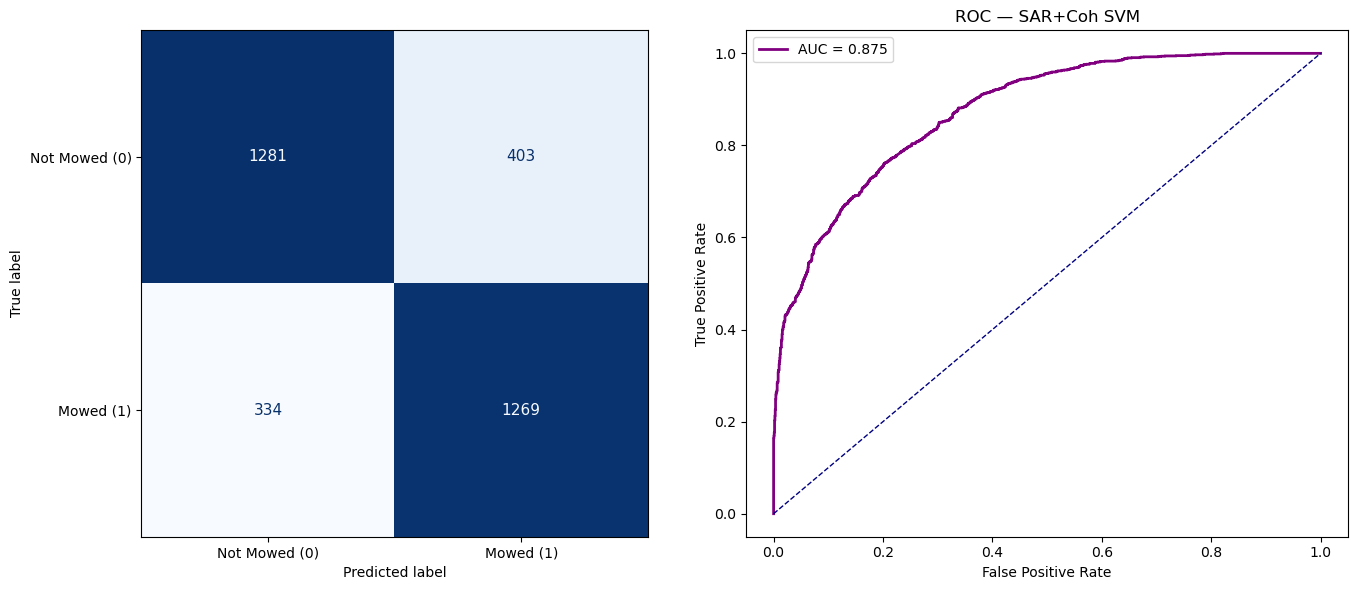

In [31]:
X_train_sc = X_train_coh_all[SAR_FEATURES + COH_FEATURES]
X_test_sc  = X_test_coh_all[SAR_FEATURES + COH_FEATURES]

print('=== Config 6: SAR+Coh (10 features) ===')
model_sc_rf = train_tuned_rf(
    X_train_sc, y_train_coh, groups_train_coh, X_test_sc, y_test_coh,
    results_list=coh_results, model_alias='SAR+Coh RF'
)
model_sc_svm = train_tuned_svm(
    X_train_sc, y_train_coh, groups_train_coh, X_test_sc, y_test_coh,
    results_list=coh_results, model_alias='SAR+Coh SVM'
)


### Config 7: S2 + Coherence (24 features)

Replaces GRD backscatter with coherence alongside optical features.
Tests whether coherence is a better SAR complement to S2 than backscatter.

=== Config 7: S2+Coh (24 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2+Coh RF ---
Accuracy: 89.11%
               precision    recall  f1-score   support

Not Mowed (0)       0.93      0.85      0.89      1684
    Mowed (1)       0.85      0.94      0.89      1603

     accuracy                           0.89      3287
    macro avg       0.89      0.89      0.89      3287
 weighted avg       0.89      0.89      0.89      3287



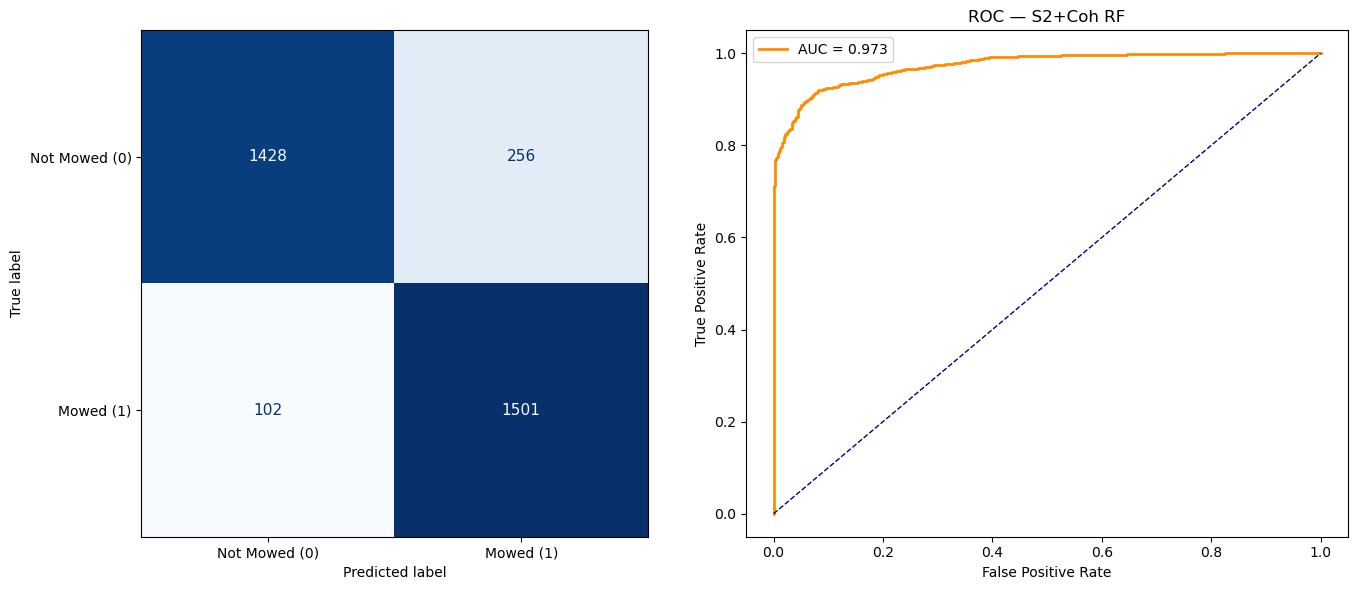

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- S2+Coh SVM ---
Accuracy: 96.78%
               precision    recall  f1-score   support

Not Mowed (0)       0.98      0.95      0.97      1684
    Mowed (1)       0.95      0.98      0.97      1603

     accuracy                           0.97      3287
    macro avg       0.97      0.97      0.97      3287
 weighted avg       0.97      0.97      0.97      3287



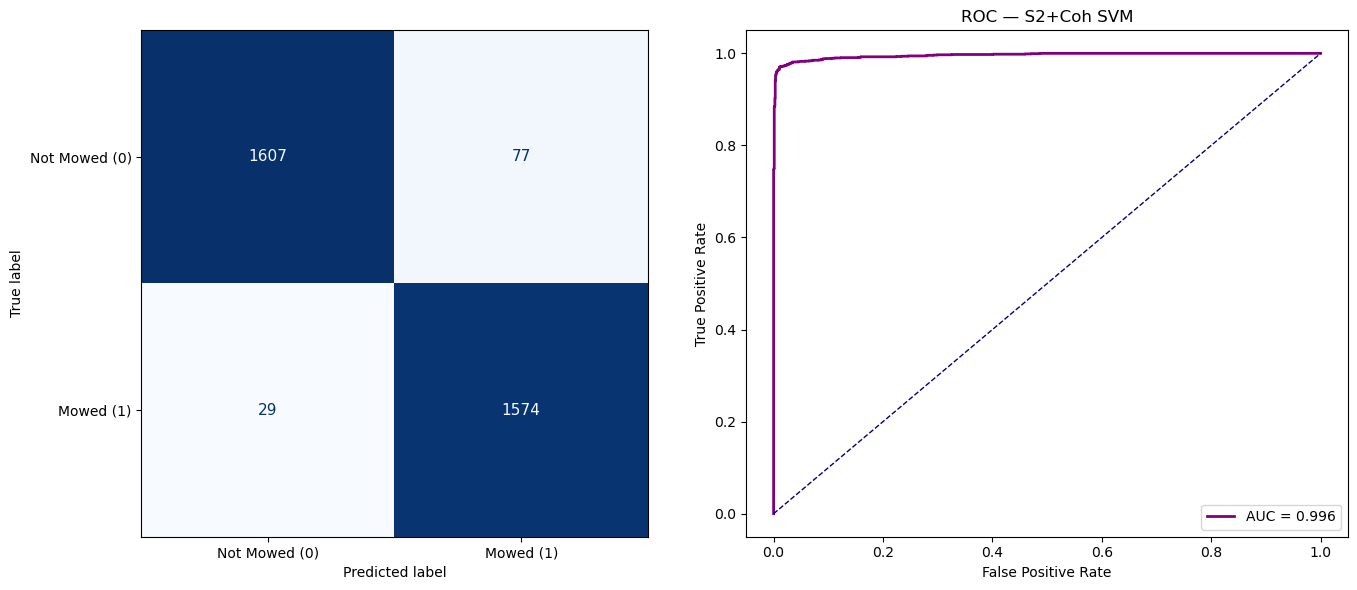

In [32]:
X_train_s2c = X_train_coh_all[FEATURE_NAMES + COH_FEATURES]
X_test_s2c  = X_test_coh_all[FEATURE_NAMES + COH_FEATURES]

print('=== Config 7: S2+Coh (24 features) ===')
model_s2c_rf = train_tuned_rf(
    X_train_s2c, y_train_coh, groups_train_coh, X_test_s2c, y_test_coh,
    results_list=coh_results, model_alias='S2+Coh RF'
)
model_s2c_svm = train_tuned_svm(
    X_train_s2c, y_train_coh, groups_train_coh, X_test_s2c, y_test_coh,
    results_list=coh_results, model_alias='S2+Coh SVM'
)


### Config 8: S2 + SAR + Coherence — Full Fusion (30 features)

All available features. Establishes the performance ceiling when every modality is combined.

=== Config 8: S2+SAR+Coh full fusion (30 features) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 200}

--- S2+SAR+Coh RF ---
Accuracy: 90.42%
               precision    recall  f1-score   support

Not Mowed (0)       0.93      0.88      0.90      1684
    Mowed (1)       0.88      0.93      0.90      1603

     accuracy                           0.90      3287
    macro avg       0.90      0.90      0.90      3287
 weighted avg       0.91      0.90      0.90      3287



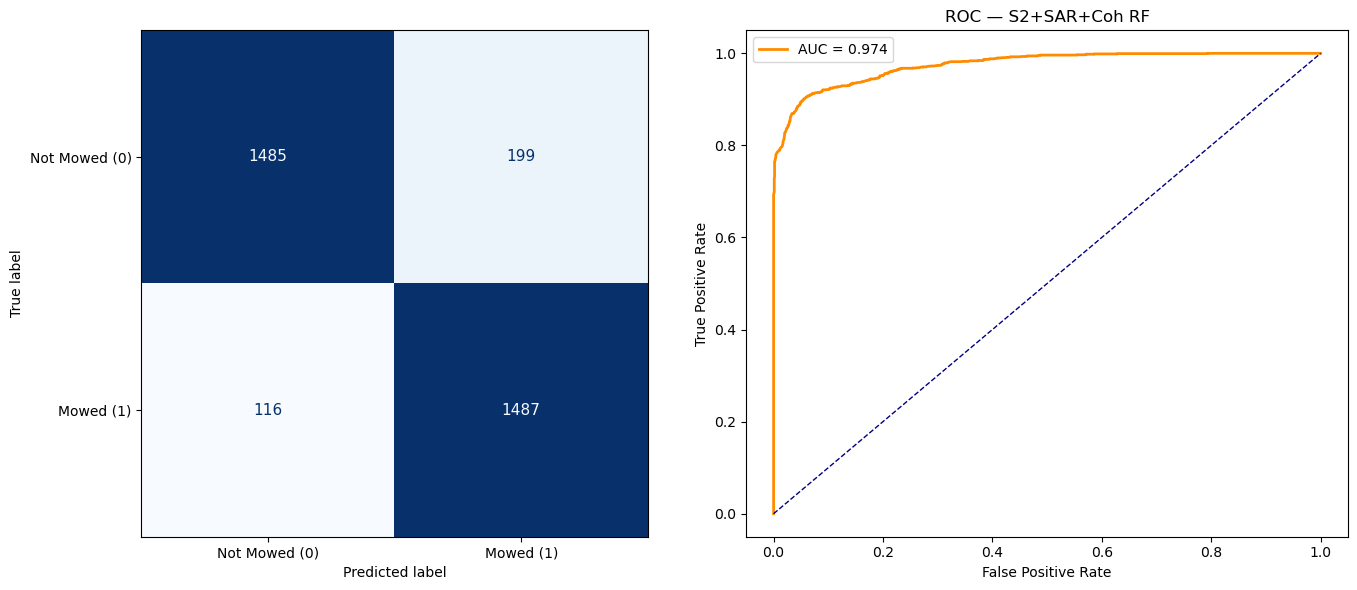

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- S2+SAR+Coh SVM ---
Accuracy: 96.50%
               precision    recall  f1-score   support

Not Mowed (0)       0.97      0.96      0.97      1684
    Mowed (1)       0.96      0.97      0.96      1603

     accuracy                           0.97      3287
    macro avg       0.96      0.97      0.96      3287
 weighted avg       0.97      0.97      0.97      3287



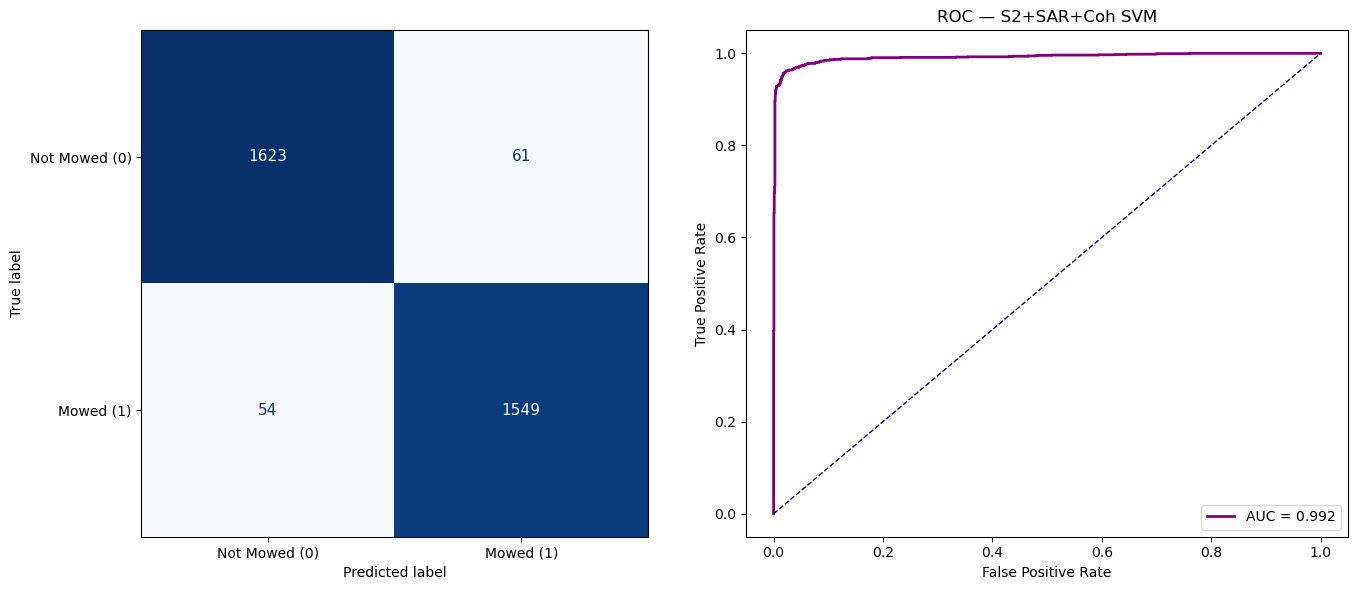

In [33]:
X_train_full = X_train_coh_all[all_coh_features]
X_test_full  = X_test_coh_all[all_coh_features]

print('=== Config 8: S2+SAR+Coh full fusion (30 features) ===')
model_full_rf = train_tuned_rf(
    X_train_full, y_train_coh, groups_train_coh, X_test_full, y_test_coh,
    results_list=coh_results, model_alias='S2+SAR+Coh RF'
)
model_full_svm = train_tuned_svm(
    X_train_full, y_train_coh, groups_train_coh, X_test_full, y_test_coh,
    results_list=coh_results, model_alias='S2+SAR+Coh SVM'
)


---
## 6. Results Summary

In [34]:
cols = ['Model', 'Num_Features', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'TP', 'FP', 'FN']
results_df = pd.DataFrame(results)
coh_results_df = pd.DataFrame(coh_results)

print('=== GRD Group (63 events) ===')
print(results_df[cols].sort_values('F1_Score', ascending=False).to_string(index=False))
print()
print('=== Coherence Group (coherence-eligible events only) ===')
print(coh_results_df[cols].sort_values('F1_Score', ascending=False).to_string(index=False))


=== GRD Group (63 events) ===
           Model  Num_Features  Precision   Recall  F1_Score  ROC_AUC   TP   FP   FN
   Hybrid+SAR RF            10   0.922302 0.916301  0.916605    0.963 4140  124  581
     S2-only SVM            20   0.924345 0.915232  0.915538    0.970 4077   70  644
      S2-only RF            20   0.918878 0.910602  0.910928    0.963 4072  104  649
S2+S1 Fusion SVM            26   0.917816 0.909652  0.909983    0.972 4070  110  651
 S2+S1 Fusion RF            26   0.913877 0.907159  0.907499    0.962 4087  148  634
  Hybrid+SAR SVM            10   0.912962 0.907159  0.907495    0.963 4106  167  615
      S1-only RF             6   0.526508 0.535320  0.527498    0.522 3102 2295 1619
     S1-only SVM             6   0.525691 0.554553  0.476482    0.530 4193 3224  528

=== Coherence Group (coherence-eligible events only) ===
         Model  Num_Features  Precision   Recall  F1_Score  ROC_AUC   TP  FP  FN
    S2+Coh SVM            24   0.968174 0.967752  0.967756    0.99

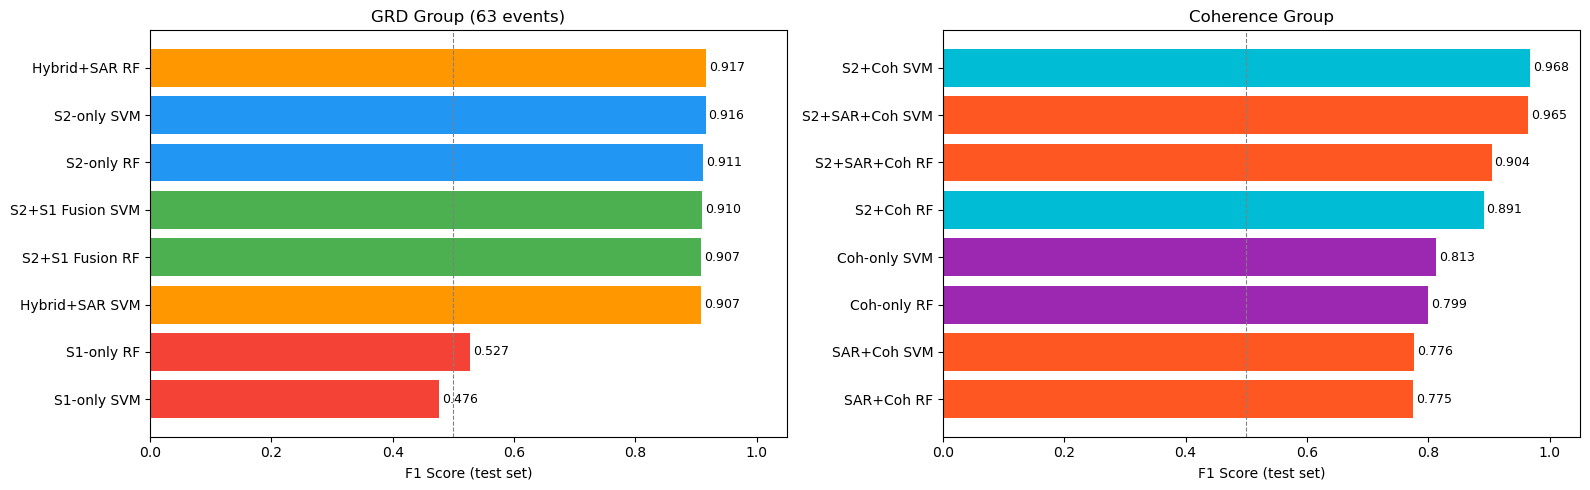

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def _bar_chart(ax, df, title):
    color_map = {
        'S2': '#2196F3', 'S1': '#F44336', 'Coh': '#9C27B0',
        'Fusion': '#4CAF50', 'Hybrid': '#FF9800', 'SAR': '#FF5722', 'Full': '#009688'
    }
    colors = []
    for m in df['Model']:
        if 'S2-only' in m:    colors.append('#2196F3')
        elif 'S1-only' in m:  colors.append('#F44336')
        elif 'Coh-only' in m: colors.append('#9C27B0')
        elif 'SAR+Coh' in m:  colors.append('#FF5722')
        elif 'S2+Coh' in m:   colors.append('#00BCD4')
        elif 'Full' in m or 'S2+SAR+Coh' in m: colors.append('#009688')
        elif 'Fusion' in m:   colors.append('#4CAF50')
        else:                  colors.append('#FF9800')
    bars = ax.barh(df['Model'], df['F1_Score'], color=colors)
    ax.set_xlabel('F1 Score (test set)')
    ax.set_title(title)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, df['F1_Score']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

_bar_chart(axes[0], results_df.sort_values('F1_Score'), 'GRD Group (63 events)')
_bar_chart(axes[1], coh_results_df.sort_values('F1_Score'), 'Coherence Group')
plt.tight_layout()
plt.show()


---
## 7. Save Best Fusion Model

In [36]:
# Identify the best fusion model (highest F1 among S2+S1 configs)
fusion_results = results_df[results_df['Model'].str.contains('Fusion')]
best_fusion_row = fusion_results.loc[fusion_results['F1_Score'].idxmax()]
best_fusion_name = best_fusion_row['Model']

model_map = {
    'S2+S1 Fusion RF':  model_fusion_rf,
    'S2+S1 Fusion SVM': model_fusion_svm,
}
best_fusion_model = model_map[best_fusion_name]
best_fusion_features = FEATURE_NAMES + SAR_FEATURES

out_path = os.path.join(MODELS_DIR, 'fusion_best.joblib')
joblib.dump({'model': best_fusion_model, 'features': best_fusion_features}, out_path)
print(f'Best fusion model: {best_fusion_name}  (F1={best_fusion_row["F1_Score"]:.3f})')
print(f'Saved to:          {out_path}')

# Also save S2-only retrained model for the 2x2 table in notebook 07
best_s2_row = results_df[results_df['Model'].str.contains('S2-only')].loc[
    results_df[results_df['Model'].str.contains('S2-only')]['F1_Score'].idxmax()
]
best_s2_model = model_s2_rf if 'RF' in best_s2_row['Model'] else model_s2_svm
s2_out = os.path.join(MODELS_DIR, 's2only_retrained.joblib')
joblib.dump({'model': best_s2_model, 'features': FEATURE_NAMES}, s2_out)
print(f'S2-only model (retrained): {best_s2_row["Model"]}  (F1={best_s2_row["F1_Score"]:.3f})')
print(f'Saved to: {s2_out}')

# Save best coherence full-fusion model (highest F1 among S2+SAR+Coh configs)
full_coh_results = coh_results_df[coh_results_df['Model'].str.contains(r'S2\+SAR\+Coh', regex=True, na=False)]

if not full_coh_results.empty:
    best_full_row = full_coh_results.loc[full_coh_results['F1_Score'].idxmax()]
    
    coh_model_map = {
        'S2+SAR+Coh RF':  model_full_rf,
        'S2+SAR+Coh SVM': model_full_svm,
    }
    
    best_full_model = coh_model_map[best_full_row['Model']]
    coh_out = os.path.join(MODELS_DIR, 'fusion_coh_best.joblib')
    joblib.dump({'model': best_full_model, 'features': all_coh_features}, coh_out)
    
    print(f"Best S2+SAR+Coh model: {best_full_row['Model']} (F1={best_full_row['F1_Score']:.3f})")
    print(f"Saved to: {coh_out}")
else:
    print("No S2+SAR+Coh models found")



# Save best S2+Coh model (24 features: FEATURE_NAMES + COH_FEATURES)
s2coh_results = coh_results_df[
    coh_results_df['Model'].str.contains(r'S2\+Coh', regex=True, na=False) &
    ~coh_results_df['Model'].str.contains('SAR', na=False)
]
if not s2coh_results.empty:
    best_s2coh_row   = s2coh_results.loc[s2coh_results['F1_Score'].idxmax()]
    s2coh_model_map  = {'S2+Coh RF': model_s2c_rf, 'S2+Coh SVM': model_s2c_svm}
    best_s2coh_model = s2coh_model_map[best_s2coh_row['Model']]
    joblib.dump({'model': best_s2coh_model, 'features': FEATURE_NAMES + COH_FEATURES},
                os.path.join(MODELS_DIR, 's2coh_best.joblib'))
    print(f'S2+Coh:   {best_s2coh_row["Model"]}  F1={best_s2coh_row["F1_Score"]:.3f}  -> s2coh_best.joblib')
else:
    print('No S2+Coh models found — run coherence section first')

# Save best Coh-only model (4 features: COH_FEATURES)
co_results = coh_results_df[coh_results_df['Model'].str.contains('Coh-only', na=False)]
if not co_results.empty:
    best_co_row   = co_results.loc[co_results['F1_Score'].idxmax()]
    co_model_map  = {'Coh-only RF': model_co_rf, 'Coh-only SVM': model_co_svm}
    best_co_model = co_model_map[best_co_row['Model']]
    joblib.dump({'model': best_co_model, 'features': COH_FEATURES},
                os.path.join(MODELS_DIR, 'coh_only_best.joblib'))
    print(f'Coh-only: {best_co_row["Model"]}  F1={best_co_row["F1_Score"]:.3f}  -> coh_only_best.joblib')
else:
    print('No Coh-only models found — run coherence section first')


Best fusion model: S2+S1 Fusion SVM  (F1=0.910)
Saved to:          ..\models\fusion_best.joblib
S2-only model (retrained): S2-only SVM  (F1=0.916)
Saved to: ..\models\s2only_retrained.joblib
Best S2+SAR+Coh model: S2+SAR+Coh SVM (F1=0.965)
Saved to: ..\models\fusion_coh_best.joblib
S2+Coh:   S2+Coh SVM  F1=0.968  -> s2coh_best.joblib
Coh-only: Coh-only SVM  F1=0.813  -> coh_only_best.joblib


In [37]:
# Additionally save best coherence-only model for notebook 07
coh_only_results = coh_results_df[coh_results_df['Model'].str.contains('Coh-only', regex=True, na=False)]
if not coh_only_results.empty:
    best_coh_row = coh_only_results.loc[coh_only_results['F1_Score'].idxmax()]
    
    coh_only_model_map = {
        'Coh-only RF':  model_co_rf,
        'Coh-only SVM': model_co_svm,
    }
    
    best_coh_model = coh_only_model_map[best_coh_row['Model']]
    coh_only_out = os.path.join(MODELS_DIR, 'cohonly_best.joblib')
    joblib.dump({'model': best_coh_model, 'features': COH_FEATURES}, coh_only_out)
    
    print(f"Best Coherence-only model: {best_coh_row['Model']} (F1={best_coh_row['F1_Score']:.3f})")
    print(f"Saved to: {coh_only_out}")

Best Coherence-only model: Coh-only SVM (F1=0.813)
Saved to: ..\models\cohonly_best.joblib


---
## Summary

**What this notebook produced:**
- Test-set F1, precision, recall, ROC-AUC for 8 models (4 configs × 2 algorithms)
- `models/fusion_best.joblib` — best S2+S1 fusion model + feature list
- `models/s2only_retrained.joblib` — S2-only baseline retrained on the same event subset

**Key design decision:** All configs share the same GroupShuffleSplit — no test set leakage,
and results are directly comparable across feature sets.

**Next step → notebook 07:** Apply the saved models to the held-out 2020-08-12 full scene
to populate the 2×2 operational evaluation table.